In [1]:
## Load libraries
import os
import pandas as pd
import TaxSolver as tx
from TaxSolver.data_wrangling.data_loader import DataLoader
from TaxSolver.data_wrangling.bracket_input import BracketInput
from TaxSolver.constraints.budget_constraint import BudgetConstraint
from TaxSolver.constraints.income_constraint import IncomeConstraint
from TaxSolver.constraints.marginal_pressure_constraint import MarginalPressureConstraint
from TaxSolver.constraints.bracket_constraint import BracketConstraint
from TaxSolver.backend import GurobiBackend
from TaxSolver.objective import BudgetObjective

#### Case 1, recover 2

In [2]:
## Load data
file_path = os.path.join('data', 'simple_simul_1000.xlsx')
df_taxpayers = pd.read_excel(file_path)
df_taxpayers['tax'] = df_taxpayers['income_before_tax'] - df_taxpayers['outcome_2']
df_taxpayers['hh_id'] = df_taxpayers.index
df_taxpayers.rename(columns={"tax_2_children": "sq_a_tax_2_children"}, inplace=True)
df_taxpayers["sq_m_tax_2_children"] = 0

In [3]:
dl = DataLoader(path=df_taxpayers, income_before_tax="income_before_tax", income_after_tax="outcome_2")

tax_solver = tx.TaxSolver(
    dl.households,
    backend=GurobiBackend(),
    )

inflection_points = [0, 25_000, 30_000, 40_000, 50_000, 75_000, 100_000, 150_000]

BracketInput.add_split_variables_to_solver(
    tx=tax_solver,
    target_var="income_before_tax",
    inflection_points=inflection_points,
    group_vars=["k_everybody"],
)

income_tax = tx.BracketRule(
    name="income_before_tax_k_everybody",
    var_name="income_before_tax",
    k_group_var="k_everybody",
    ub=1,
    lb=0,
)

child_benefit = tx.BenefitRule(
    name="child_benefit",
    var_name="i_children",
)

universal_benefit = tx.BenefitRule(
    name="universal_benefit",
    var_name="k_everybody",
)

tax_solver.add_rules([income_tax, child_benefit, universal_benefit])

income_constraint = IncomeConstraint(0.0000001, dl.households.values())

# No budget bound: the loose cap below is non-binding and only keeps the
# spend variable that defines the revenue-loss objective
budget_constraint = BudgetConstraint(
    "All_households", dl.households.values(), 1_000_000_000
)

tax_solver.add_constraints([income_constraint, budget_constraint])

objective = BudgetObjective(budget_constraint)
tax_solver.add_objective(objective)

tax_solver.solve()

r_and_r = tax_solver.rules_and_rates_table()
r_and_r_recover_c2 = r_and_r.copy()  # consumed by the figure cell
r_and_r

Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Mirror household were missing for 1000 households: set to own id
Set parameter Username


Academic license - for non-commercial use only - expires 2027-07-08


Current tax balance All_households: -18519479
New Maximum: 981480521
Going to solve!
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 24.6.0 24G720)


CPU model: Apple M4 Max


Thread count: 16 physical cores, 16 logical processors, using up to 16 threads


...

Solution count 1: 537.9 


Optimal solution found (tolerance 1.00e-04)


Best objective 5.378997080028e+02, best bound 5.378997079991e+02, gap 0.0000%


Found at least one feasible solution!


,rule_name,rule_type,var_name,rate,b,weight
0,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_0_25000,0.10000,1,1
1,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_25000_30000,0.19996,1,1
2,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_30000_40000,0.35000,1,1
3,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_40000_50000,0.20002,1,1
4,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_50000_75000,0.30000,1,1
5,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_75000_100000,0.40000,1,1
6,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_100000_150000,0.50000,1,1
7,child_benefit,BenefitRule,i_children,799.99992,1,1
8,universal_benefit,BenefitRule,k_everybody,1500.49985,1,1


#### Case 1, reform 2

In [4]:
dl = DataLoader(path=df_taxpayers, income_before_tax="income_before_tax", income_after_tax="outcome_2")

tax_solver = tx.TaxSolver(
    dl.households,
    backend=GurobiBackend(),
    )

inflection_points = [0, 25_000, 50_000, 75_000, 100_000, 1_000_000]

BracketInput.add_split_variables_to_solver(
    tx=tax_solver,
    target_var="income_before_tax",
    inflection_points=inflection_points,
    group_vars=["k_everybody"],
)

# 1. Progressive income tax brackets with rate_lb=0
income_tax = tx.BracketRule(
    name="income_before_tax_k_everybody",
    var_name="income_before_tax",
    k_group_var="k_everybody",
    ub=1,
    lb=0,
)

# 2. Existing child benefit - keep same as existing (lb=1, ub=1 means rate fixed at 1)
existing_child_benefit = tx.ExistingBenefit(
    name="existing_child_benefit",
    var_name="tax_2_children",  # Will use sq_a_tax_2_children and sq_m_tax_2_children
    lb=1,
    ub=1,
    weight=10,
)

universal_benefit = tx.BenefitRule(
    name="universal_benefit",
    var_name="k_everybody",
)

tax_solver.add_rules([income_tax, existing_child_benefit, universal_benefit])

# Add constraints
income_constraint = IncomeConstraint(0.10, dl.households.values())

# Household group <70k: must gain at least 5% (new_income >= old_income * 1.05)
low_income_households = [
    hh for hh in dl.households.values() 
    if hh.members[0]["income_before_tax"] < 70_000
]
income_constraint_low_income = IncomeConstraint(-0.05, low_income_households)

# No budget bound: the loose cap below is non-binding and only keeps the
# spend variable that defines the revenue-loss objective
budget_constraint = BudgetConstraint(
    "All_households", dl.households.values(), 1_000_000_000
)

marginal_pressure_constraint = MarginalPressureConstraint(0.6)

tax_solver.add_constraints([
    income_constraint, 
    income_constraint_low_income,
    budget_constraint, 
    marginal_pressure_constraint
])

# Create BracketConstraint for ascending rates
bracket_constraint = BracketConstraint(
    rule_family="income_before_tax_k_everybody",
    max_brackets=None,  # No limit on number of brackets
    ascending=True,     # Rates must be ascending
    start_from_first_inflection=False,
    last_bracket_zero=False,
)
bracket_constraint.brackets = income_tax.flat_rules
tax_solver.add_constraints([bracket_constraint])

objective = BudgetObjective(budget_constraint)
tax_solver.add_objective(objective)

tax_solver.solve()

r_and_r = tax_solver.rules_and_rates_table()
r_and_r_reform2_c2 = r_and_r.copy()  # consumed by the figure cell
r_and_r

Directly loading from pd.DataFrame...
Using 'income_after_tax' as the income before tax column.
Mirror household were missing for 1000 households: set to own id


Current tax balance All_households: -18519479
New Maximum: 981480521
Going to solve!
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 24.6.0 24G720)


CPU model: Apple M4 Max


Thread count: 16 physical cores, 16 logical processors, using up to 16 threads


Optimize a model with 4433 rows, 1017 columns and 8862 nonzeros


...

No other solutions better than -555872


Optimal solution found (tolerance 1.00e-04)


Best objective -5.558721562707e+05, best bound -5.558721562707e+05, gap 0.0000%


Found at least one feasible solution!


,rule_name,rule_type,var_name,rate,b,weight
0,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_0_25000,0.054986,1,1
1,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_25000_50000,0.160032,1,1
2,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_50000_75000,0.349642,1,1
3,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_75000_100000,0.600000,1,1
4,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_100000_1000000,0.600000,1,1
5,existing_child_benefit,ExistingBenefit,sq_a_tax_2_children,1.000000,1,10
6,universal_benefit,BenefitRule,k_everybody,1695.211201,1,1


In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

Y_TITLE = "Taxes paid (€)"
X_TITLE = "Income before tax (€)"
TICK_FONT_SIZE = 14

# Use RdYlBu colormap colors (blue for current, red for reform)
cmap = plt.cm.RdYlBu
COLOR_CURRENT = '#0072B2'  # Okabe-Ito blue: current system
COLOR_REFORM = '#D55E00'   # Okabe-Ito vermillion: TaxSolver reform

# Jude and Laila colors
JL_COLOR = '#E69F00'  # Okabe-Ito orange
JL_ALPHA = 0.8

def euro_format(x, pos):
    """Format numbers as euro amounts with K for thousands."""
    return f"€{x/1000:.0f}K"

def wrangle_intervals(df_intervals, df_taxpayers, filter_var=None):
    """Set max bracket to observed max income."""
    df_intervals = df_intervals.copy()
    if filter_var:
        df_intervals = df_intervals.loc[df_intervals["target_var"] == filter_var]
    # Reset index after filtering to avoid iloc issues
    df_intervals = df_intervals.reset_index(drop=True)
    df_intervals.iloc[-1, df_intervals.columns.get_loc("bracket_end")] = df_taxpayers["income_before_tax"].max()
    return df_intervals

def build_tax_line(df_intervals, start_y=0):
    """Build x,y values for a tax line from bracket intervals."""
    x_values = []
    y_values = []
    current_y = start_y
    
    for _, row in df_intervals.iterrows():
        x_start, x_end, rate = row["bracket_start"], row["bracket_end"], row["rate"]
        x_interval = [x_start, x_end]
        y_interval = [current_y, current_y + (x_end - x_start) * rate]
        x_values.extend(x_interval)
        y_values.extend(y_interval)
        current_y = y_interval[1]
    
    return x_values, y_values, current_y

# Load taxpayer data (use first 100 for simple visualization)
file_path_plot = os.path.join('data', 'simple_simul_1000.xlsx')
df_taxpayers_plot = pd.read_excel(file_path_plot)
df_taxpayers_plot = df_taxpayers_plot.iloc[0:100, :].copy()
df_taxpayers_plot["tax_2"] = df_taxpayers_plot["income_before_tax"] - df_taxpayers_plot["outcome_2"]

print(f"Loaded {len(df_taxpayers_plot)} taxpayers for visualization")


Loaded 100 taxpayers for visualization


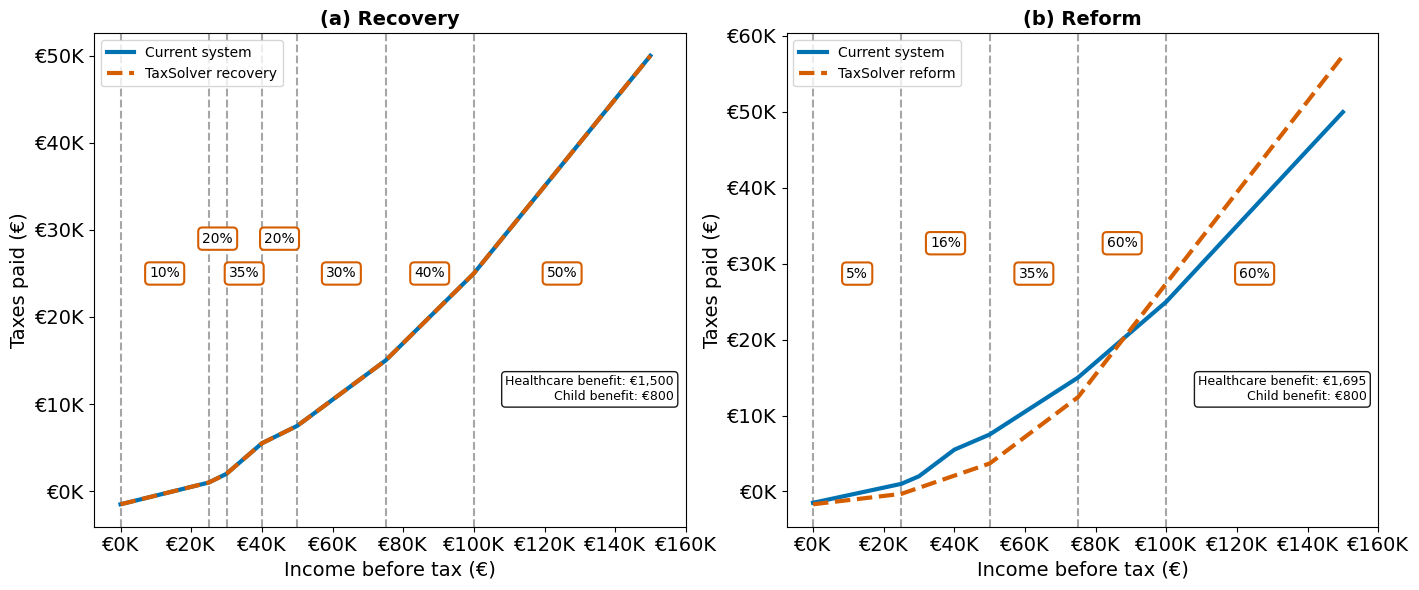

Plot saved to ./output/figs/case_1b_combined.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Everything below is built from the data-generating parameters and this
# notebook's own solves.
from case_helpers import rates_to_intervals, benefit_value
from parameters import default_params

p = default_params
base = p["tax_brackets"]["all"]
taper_rate = p["zvw_benefit"]["ztafb"]
taper_start = p["zvw_benefit"]["wml"]
taper_end = taper_start + p["zvw_benefit"]["zt_a"] / taper_rate
HC_TRUE = p["zvw_benefit"]["zt_a"]          # healthcare lump sum (current system)
CHILD_TRUE = p["child_benefits"][0]["benefit"]

# Current system: base brackets with the healthcare taper folded in on
# [taper_start, taper_end]
df_intervals_true = pd.DataFrame([
    {"bracket_start": 0,           "bracket_end": base[0]["income_up_to"], "rate": base[0]["rate"]},
    {"bracket_start": base[0]["income_up_to"], "bracket_end": taper_start, "rate": base[1]["rate"]},
    {"bracket_start": taper_start, "bracket_end": taper_end,               "rate": base[1]["rate"] + taper_rate},
    {"bracket_start": taper_end,   "bracket_end": base[1]["income_up_to"], "rate": base[1]["rate"]},
    {"bracket_start": base[1]["income_up_to"], "bracket_end": base[2]["income_up_to"], "rate": base[2]["rate"]},
    {"bracket_start": base[2]["income_up_to"], "bracket_end": base[3]["income_up_to"], "rate": base[3]["rate"]},
    {"bracket_start": base[3]["income_up_to"], "bracket_end": 1_000_000,   "rate": base[4]["rate"]},
])
df_intervals_true = wrangle_intervals(df_intervals_true, df_taxpayers_plot)
x_true, y_true, current_y_true = build_tax_line(df_intervals_true, start_y=0)
y_true = [y - HC_TRUE for y in y_true]

# Recovery (from this notebook's recovery solve)
HC_RECOVER = benefit_value(r_and_r_recover_c2, "universal_benefit")
CHILD_RECOVER = benefit_value(r_and_r_recover_c2, "child_benefit")
df_intervals_recover = rates_to_intervals(r_and_r_recover_c2)
df_intervals_recover = wrangle_intervals(df_intervals_recover, df_taxpayers_plot)
x_recover, y_recover, current_y_recover = build_tax_line(df_intervals_recover, start_y=-HC_RECOVER)

# Reform (from this notebook's reform solve: 5 brackets, child benefit fixed,
# >=5% net-income gain below EUR 70k)
HC_REFORM = benefit_value(r_and_r_reform2_c2, "universal_benefit")
df_intervals_reform2 = rates_to_intervals(r_and_r_reform2_c2)
df_intervals_reform2 = wrangle_intervals(df_intervals_reform2, df_taxpayers_plot)
x_reform2, y_reform2, current_y_reform2 = build_tax_line(df_intervals_reform2, start_y=-HC_REFORM)

# ========== PLOT 1: Recovery ==========
ax1 = axes[0]

for income in [0, 25_000, 30_000, 40_000, 50_000, 75_000, 100_000]:
    ax1.axvline(x=income, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax1.plot(x_true, y_true, label="Current system", color=COLOR_CURRENT, linestyle="-", linewidth=3)
ax1.plot(x_recover, y_recover, label="TaxSolver recovery", color=COLOR_REFORM, linestyle="--", linewidth=3)

for i, row in df_intervals_recover.iterrows():
    x_mid = (row["bracket_start"] + row["bracket_end"]) / 2
    # Raise 2nd and 4th brackets (index 1 and 3) to avoid overlap
    y_mid = current_y_recover / 2 + (4000 if i in [1, 3] else 0)
    rate_text = f"{row['rate']:.0%}"
    ax1.text(x_mid, y_mid, rate_text, fontsize=10, color="black",
            ha="center", va="center",
            bbox=dict(facecolor="white", edgecolor=COLOR_REFORM, linestyle="-", linewidth=1.5, boxstyle="round,pad=0.3"))

ax1.text(0.98, 0.25, f"Healthcare benefit: €{HC_RECOVER:,.0f}\nChild benefit: €{CHILD_RECOVER:,.0f}", 
         transform=ax1.transAxes, fontsize=9, color="black",
         ha="right", va="bottom",
         bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3", alpha=0.9))

ax1.set_xlabel(X_TITLE, fontsize=14)
ax1.set_ylabel(Y_TITLE, fontsize=14)
ax1.xaxis.set_major_formatter(FuncFormatter(euro_format))
ax1.yaxis.set_major_formatter(FuncFormatter(euro_format))
ax1.tick_params(axis='both', labelsize=TICK_FONT_SIZE)
ax1.set_xlim(right=160_000)
ax1.legend(fontsize=10, loc='upper left')
ax1.set_title("(a) Recovery", fontsize=14, fontweight='bold')

# ========== PLOT 2: Reform 2 (5 brackets) ==========
ax2 = axes[1]

for income in [0, 25_000, 50_000, 75_000, 100_000]:
    ax2.axvline(x=income, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax2.plot(x_true, y_true, label="Current system", color=COLOR_CURRENT, linestyle="-", linewidth=3)
ax2.plot(x_reform2, y_reform2, label="TaxSolver reform", color=COLOR_REFORM, linestyle="--", linewidth=3)

for i, row in df_intervals_reform2.iterrows():
    x_mid = (row["bracket_start"] + row["bracket_end"]) / 2
    # Raise 2nd and 4th brackets (index 1 and 3) to avoid overlap
    y_mid = current_y_reform2 / 2 + (4000 if i in [1, 3] else 0)
    rate_text = f"{row['rate']:.0%}"
    ax2.text(x_mid, y_mid, rate_text, fontsize=10, color="black",
            ha="center", va="center",
            bbox=dict(facecolor="white", edgecolor=COLOR_REFORM, linestyle="-", linewidth=1.5, boxstyle="round,pad=0.3"))

ax2.text(0.98, 0.25, f"Healthcare benefit: €{HC_REFORM:,.0f}\nChild benefit: €{CHILD_TRUE:,.0f}", 
         transform=ax2.transAxes, fontsize=9, color="black",
         ha="right", va="bottom",
         bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3", alpha=0.9))

ax2.set_xlabel(X_TITLE, fontsize=14)
ax2.set_ylabel(Y_TITLE, fontsize=14)
ax2.xaxis.set_major_formatter(FuncFormatter(euro_format))
ax2.yaxis.set_major_formatter(FuncFormatter(euro_format))
ax2.tick_params(axis='both', labelsize=TICK_FONT_SIZE)
ax2.set_xlim(right=160_000)
ax2.legend(fontsize=10, loc='upper left')
ax2.set_title("(b) Reform", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./output/figs/case_1b_combined.png', dpi=900, bbox_inches='tight')

plt.show()

print("Plot saved to ./output/figs/case_1b_combined.png")
